<a href="https://colab.research.google.com/github/vanshikapringle/Samsung_Sentiment_Research/blob/main/Samsung_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Load the CSV straight from your Drive folder
path = '/content/drive/MyDrive/Samsung_Sentiment/samsung_baseline_labeled_data.csv'
df = pd.read_csv(path)

print(f"Successfully loaded dataset with {len(df)} rows!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded dataset with 23656 rows!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 1. Clean dataset missing values
df = df.dropna(subset=["cleaned_text", "predicted_sentiment"]).reset_index(
    drop=True
)

X = df["cleaned_text"]
y = df["predicted_sentiment"]

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TF-IDF Feature Extraction
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# --- Model 1: Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

# --- Model 2: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

# 4. Generate Baseline Results Table
results = [
    {
        "Model Architecture": "TF-IDF + Naive Bayes",
        "Accuracy": round(accuracy_score(y_test, nb_preds), 4),
        "Precision (Macro)": round(
            precision_score(y_test, nb_preds, average="macro"), 4
        ),
        "Recall (Macro)": round(
            recall_score(y_test, nb_preds, average="macro"), 4
        ),
        "F1-Score (Macro)": round(
            f1_score(y_test, nb_preds, average="macro"), 4
        ),
    },
    {
        "Model Architecture": "TF-IDF + Logistic Regression",
        "Accuracy": round(accuracy_score(y_test, lr_preds), 4),
        "Precision (Macro)": round(
            precision_score(y_test, lr_preds, average="macro"), 4
        ),
        "Recall (Macro)": round(
            recall_score(y_test, lr_preds, average="macro"), 4
        ),
        "F1-Score (Macro)": round(
            f1_score(y_test, lr_preds, average="macro"), 4
        ),
    },
]

results_df = pd.DataFrame(results)
print("=== CLASSICAL BASELINE RESULTS ===")
print(results_df.to_string(index=False))

=== CLASSICAL BASELINE RESULTS ===
          Model Architecture  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
        TF-IDF + Naive Bayes    0.6811             0.6718          0.6839            0.6761
TF-IDF + Logistic Regression    0.7274             0.7285          0.7062            0.7144


In [ ]:
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# 1. Map labels to integers for PyTorch
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

df["label"] = df["predicted_sentiment"].map(label2id)

# 2. Stratified Train-Validation Split (80/20)
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

# 3. Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df[["cleaned_text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["cleaned_text", "label"]])

# 4. Tokenizer & Data Collator Setup
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# Add explicit max_length padding to fix length mismatches
def tokenize_function(examples):
    return tokenizer(
        examples["cleaned_text"],
        truncation=True,
        max_length=128,
        padding="max_length",
    )


train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# 5. Model Setup
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)


# 6. Metrics Calculation Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": round(acc, 4),
        "f1_macro": round(f1, 4),
        "precision_macro": round(precision, 4),
        "recall_macro": round(recall, 4),
    }


# 7. Training Arguments
save_dir = "/content/drive/MyDrive/Samsung_Sentiment/samsung_roberta_finetuned"

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
    fp16=True,  # GPU mixed precision
)

# 8. Trainer Execution
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting RoBERTa Fine-Tuning on GPU...\n")
trainer.train()

# 9. Save Best Model to Google Drive
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"\nFine-tuning complete! Model saved to Google Drive at: {save_dir}")

Map:   0%|          | 0/18924 [00:00<?, ? examples/s]

Map:   0%|          | 0/4732 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting RoBERTa Fine-Tuning on GPU...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.231541,0.195257,0.925600,0.926000,0.922000,0.931000
2,0.125319,0.257095,0.928600,0.928900,0.924600,0.934100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete! Model saved to Google Drive at: /content/drive/MyDrive/Samsung_Sentiment/samsung_roberta_finetuned


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [01:01<00:00, 10.69s/it]

  0%|          | 0/156 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [01:10, 23.52s/it]


Generating SHAP Plot for Negative Sentiment Attribution...


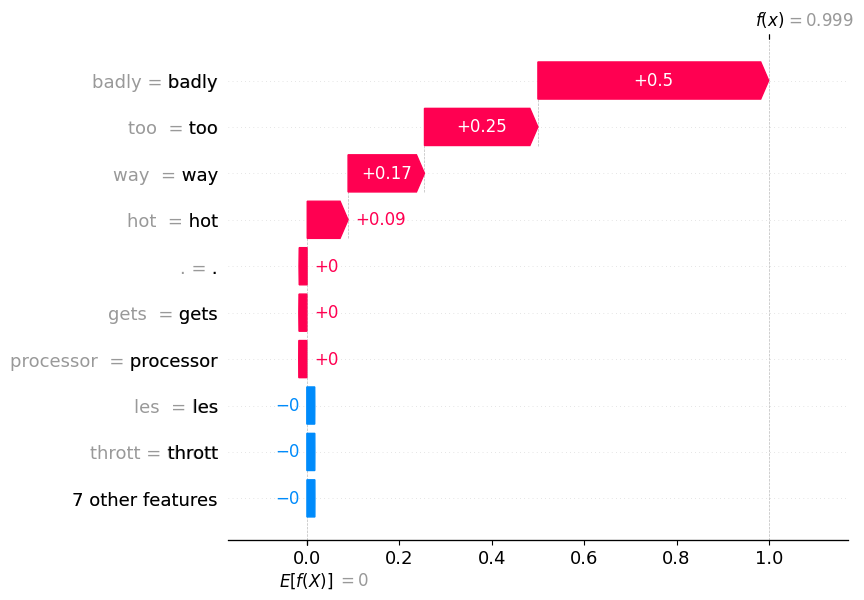

In [ ]:
import numpy as np
import pandas as pd
import shap
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Load Fine-Tuned Model from Google Drive
model_path = (
    "/content/drive/MyDrive/Samsung_Sentiment/samsung_roberta_finetuned"
)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()


# 2. Prediction Pipeline for SHAP
def predict_pipeline(texts):
    inputs = tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt",
    )
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.numpy()


# 3. Sample Representative Texts for Attribution
sample_texts = pd.Series([
    "The camera on the Galaxy S24 Ultra is absolutely stunning, battery life is amazing!",
    "Exynos processor gets way too hot and throttles performance badly.",
    "The software update was released yesterday for the fold series.",
])

# 4. Initialize Partition Explainer
explainer = shap.Explainer(predict_pipeline, tokenizer)
shap_values = explainer(sample_texts)

# 5. Display SHAP Waterfall Plot for the Negative Comment
print("Generating SHAP Plot for Negative Sentiment Attribution...")
shap.plots.waterfall(shap_values[1, :, 0])  # Class 0 = Negative

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer:   4%|▍         | 4/100 [00:14<00:40,  2.39it/s]

  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 5/100 [00:24<06:41,  4.22s/it]

...

PartitionExplainer explainer:  99%|█████████▉| 99/100 [40:22<00:31, 31.06s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [41:28<00:00, 41.29s/it]

  0%|          | 0/272 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [41:44, 25.30s/it]


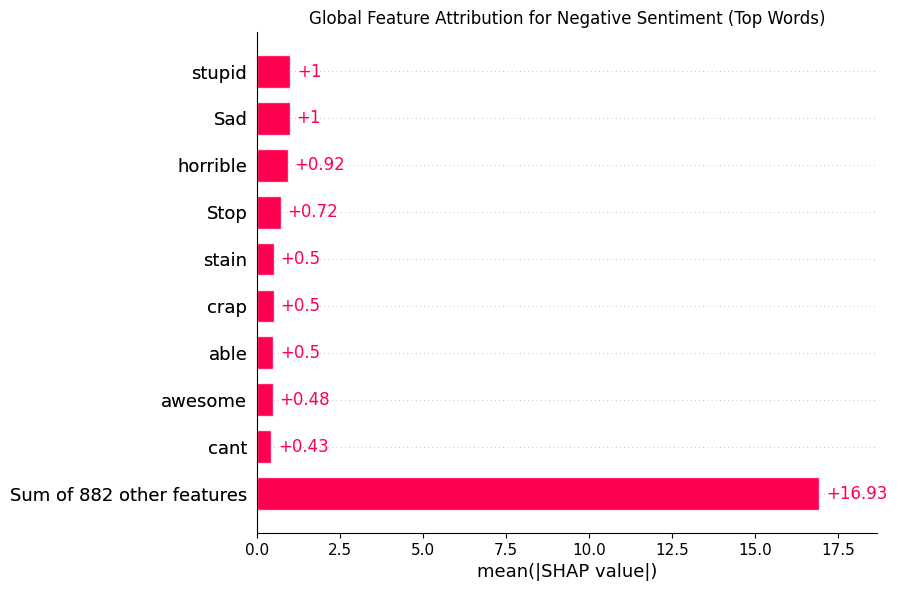

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Load Fine-Tuned Model & Tokenizer
model_path = (
    "/content/drive/MyDrive/Samsung_Sentiment/samsung_roberta_finetuned"
)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()


def predict_pipeline(texts):
    inputs = tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt",
    )
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.numpy()


# 2. Sample 100 Random Comments from Your Labeled Data
df = pd.read_csv(
    "/content/drive/MyDrive/Samsung_Sentiment/samsung_baseline_labeled_data.csv"
)
sample_subset = df["cleaned_text"].dropna().sample(n=100, random_state=42)

# 3. Compute SHAP Values across Sample
explainer = shap.Explainer(predict_pipeline, tokenizer)
shap_values_sample = explainer(sample_subset)

# 4. Generate Global Summary Bar Plot for Negative Class (Index 0)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_sample[:, :, 0], show=False)
plt.title("Global Feature Attribution for Negative Sentiment (Top Words)")
plt.savefig(
    "/content/drive/MyDrive/Samsung_Sentiment/global_shap_negative.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Samsung_Sentiment/fig4_global_shap_attribution.png",
    bbox_inches="tight",
    dpi=300,
)

<Figure size 640x480 with 0 Axes>

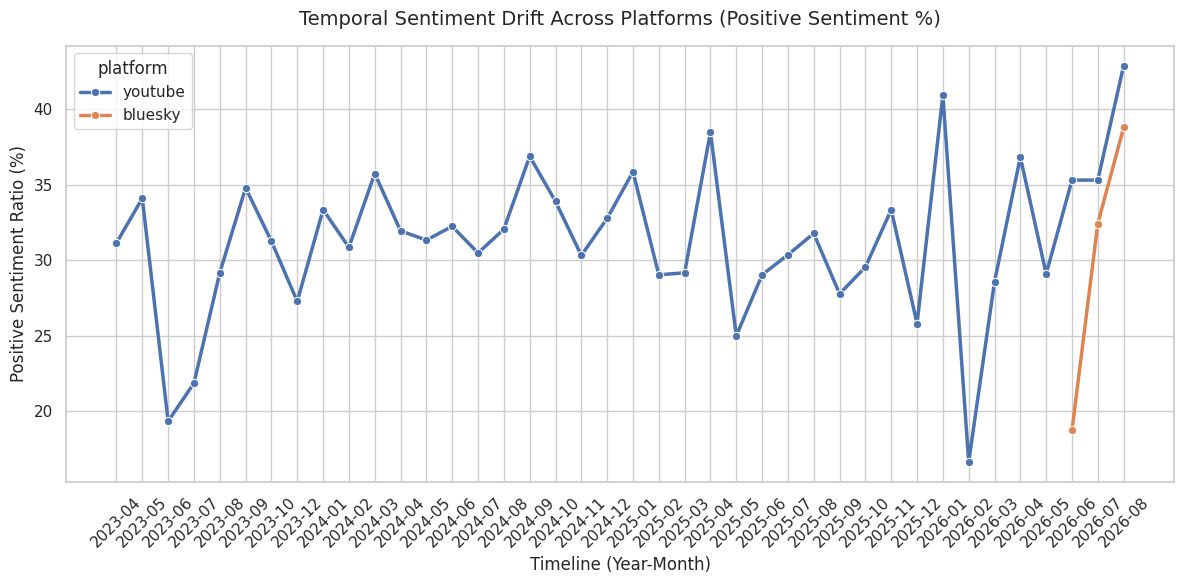

Temporal drift graph successfully created and saved to 'temporal_sentiment_drift.png'!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load baseline labeled data & parse dates
df = pd.read_csv(
    "/content/drive/MyDrive/Samsung_Sentiment/samsung_baseline_labeled_data.csv"
)
df["created_at"] = pd.to_datetime(df["created_at"])

# Extract Year-Month for temporal aggregation
df["year_month"] = df["created_at"].dt.to_period("M").astype(str)

# 2. Calculate monthly sentiment proportions per platform
monthly_sentiment = (
    df.groupby(["year_month", "platform", "predicted_sentiment"])
    .size()
    .unstack(fill_value=0)
)
monthly_sentiment["total"] = monthly_sentiment.sum(axis=1)

# Calculate percentage of Positive and Negative sentiment
monthly_sentiment["positive_pct"] = (
    monthly_sentiment["positive"] / monthly_sentiment["total"]
) * 100
monthly_sentiment["negative_pct"] = (
    monthly_sentiment["negative"] / monthly_sentiment["total"]
) * 100

monthly_df = monthly_sentiment.reset_index()

# Filter out periods with very low sample counts for clean plotting (< 10 posts)
monthly_df = monthly_df[monthly_df["total"] >= 10].sort_values("year_month")

# 3. Plot Temporal Sentiment Drift
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=monthly_df,
    x="year_month",
    y="positive_pct",
    hue="platform",
    marker="o",
    linewidth=2.5,
)

plt.title(
    "Temporal Sentiment Drift Across Platforms (Positive Sentiment %)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Timeline (Year-Month)", fontsize=12)
plt.ylabel("Positive Sentiment Ratio (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot to Google Drive
plt.savefig(
    "/content/drive/MyDrive/Samsung_Sentiment/temporal_sentiment_drift.png",
    dpi=300,
)
plt.show()

print(
    "Temporal drift graph successfully created and saved to 'temporal_sentiment_drift.png'!"
)

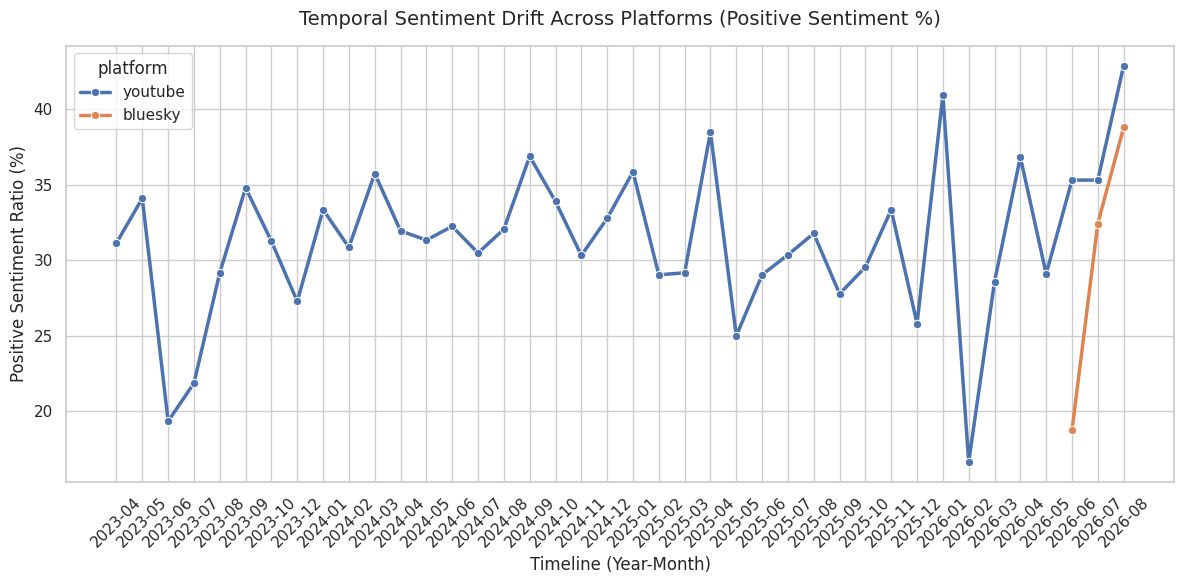

Temporal drift graph successfully created and saved to 'temporal_sentiment_drift.png'!


In [ ]:
#saving upar wala waterfall graph
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load baseline labeled data & parse dates
df = pd.read_csv(
    "/content/drive/MyDrive/Samsung_Sentiment/samsung_baseline_labeled_data.csv"
)
df["created_at"] = pd.to_datetime(df["created_at"])

# Extract Year-Month for temporal aggregation
df["year_month"] = df["created_at"].dt.to_period("M").astype(str)

# 2. Calculate monthly sentiment proportions per platform
monthly_sentiment = (
    df.groupby(["year_month", "platform", "predicted_sentiment"])
    .size()
    .unstack(fill_value=0)
)
monthly_sentiment["total"] = monthly_sentiment.sum(axis=1)

# Calculate percentage of Positive and Negative sentiment
monthly_sentiment["positive_pct"] = (
    monthly_sentiment["positive"] / monthly_sentiment["total"]
) * 100
monthly_sentiment["negative_pct"] = (
    monthly_sentiment["negative"] / monthly_sentiment["total"]
) * 100

monthly_df = monthly_sentiment.reset_index()

# Filter out periods with very low sample counts for clean plotting (< 10 posts)
monthly_df = monthly_df[monthly_df["total"] >= 10].sort_values("year_month")

# 3. Plot Temporal Sentiment Drift
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=monthly_df,
    x="year_month",
    y="positive_pct",
    hue="platform",
    marker="o",
    linewidth=2.5,
)

plt.title(
    "Temporal Sentiment Drift Across Platforms (Positive Sentiment %)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Timeline (Year-Month)", fontsize=12)
plt.ylabel("Positive Sentiment Ratio (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot to Google Drive
plt.savefig(
    "/content/drive/MyDrive/Samsung_Sentiment/temporal_sentiment_drift.png",
    dpi=300,
)
plt.show()

print(
    "Temporal drift graph successfully created and saved to 'temporal_sentiment_drift.png'!"
)